<a href="https://colab.research.google.com/github/MozaRex9/fft-case-studies-template/blob/main/Selamat_Datang_di_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!wget https://github.com/MozaRex9/fft-case-studies-template/blob/main/data/sunspots.csv

--2026-05-28 12:18:39--  https://github.com/MozaRex9/fft-case-studies-template/blob/main/data/sunspots.csv
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘sunspots.csv’

sunspots.csv            [ <=>                ] 621.52K  --.-KB/s    in 0.06s   

2026-05-28 12:18:40 (9.39 MB/s) - ‘sunspots.csv’ saved [636439]



--2026-05-28 12:28:08--  https://raw.githubusercontent.com/MozaRex9/fft-case-studies-template/main/data/sunspots.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 71184 (70K) [text/plain]
Saving to: ‘sunspots.csv’

sunspots.csv        100%[===================>]  69.52K  --.-KB/s    in 0.01s   

2026-05-28 12:28:08 (5.70 MB/s) - ‘sunspots.csv’ saved [71184/71184]

   Unnamed: 0        Date  Monthly Mean Total Sunspot Number
0           0  1749-01-31                               96.7
1           1  1749-02-28                              104.3
2           2  1749-03-31                              116.7
3           3  1749-04-30                               92.8
4           4  1749-05-31                              141.7
HASIL ANALISIS FFT
Frekuensi Domin

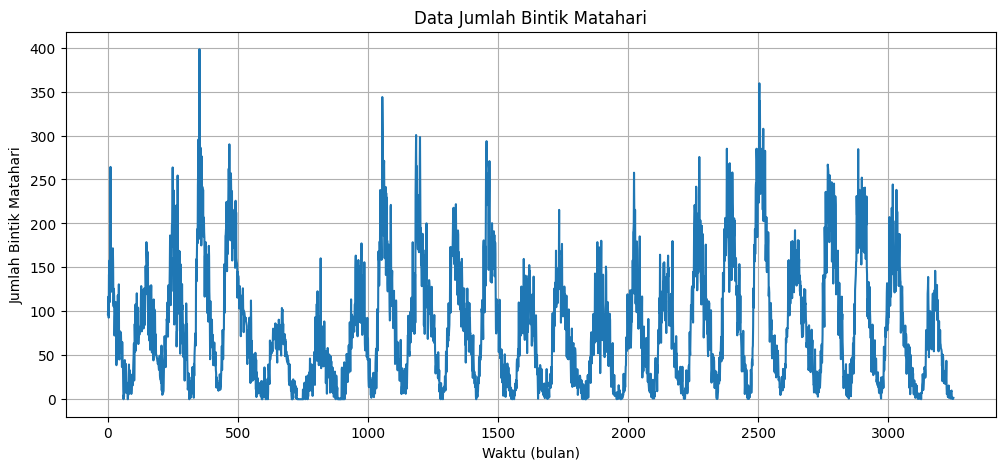

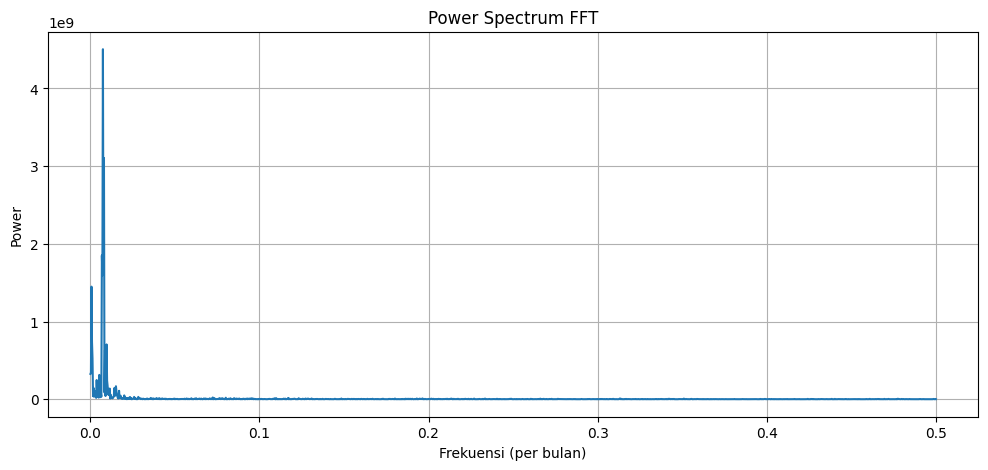

In [17]:
# ============================================
# FFT DAN POWER SPECTRUM DATA BINTIK MATAHARI
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# 1. BACA FILE CSV
# ------------------------------------------------
# Ganti nama kolom sesuai file Anda
!wget -O sunspots.csv https://raw.githubusercontent.com/MozaRex9/fft-case-studies-template/main/data/sunspots.csv
data = pd.read_csv('sunspots.csv')

print(data.head())

# ------------------------------------------------
# 2. AMBIL DATA JUMLAH BINTIK MATAHARI
# ------------------------------------------------
# Misalnya nama kolomnya 'Sunspots'
# Jika berbeda, ubah sesuai nama kolom file CSV

sunspot = data['Monthly Mean Total Sunspot Number'].values

# ------------------------------------------------
# 3. HILANGKAN NILAI RATA-RATA (DETREND)
# ------------------------------------------------
sunspot_detrend = sunspot - np.mean(sunspot)

# ------------------------------------------------
# 4. PARAMETER DATA
# ------------------------------------------------
N = len(sunspot_detrend)

# Interval waktu
# Karena data bulanan:
dt = 1  # bulan

# ------------------------------------------------
# 5. HITUNG FFT
# ------------------------------------------------
fft_result = np.fft.fft(sunspot_detrend)

# Frekuensi
freq = np.fft.fftfreq(N, d=dt)

# ------------------------------------------------
# 6. HITUNG POWER SPECTRUM
# ------------------------------------------------
power = np.abs(fft_result)**2

# ------------------------------------------------
# 7. AMBIL FREKUENSI POSITIF SAJA
# ------------------------------------------------
positive = freq > 0

freq_positive = freq[positive]
power_positive = power[positive]

# ------------------------------------------------
# 8. CARI FREKUENSI DOMINAN
# ------------------------------------------------
index_max = np.argmax(power_positive)

dominant_frequency = freq_positive[index_max]

dominant_period_month = 1 / dominant_frequency
dominant_period_year = dominant_period_month / 12

# ------------------------------------------------
# 9. TAMPILKAN HASIL
# ------------------------------------------------
print("===================================")
print("HASIL ANALISIS FFT")
print("===================================")

print(f"Frekuensi Dominan : {dominant_frequency:.6f} per bulan")
print(f"Periode Dominan   : {dominant_period_month:.2f} bulan")
print(f"Periode Dominan   : {dominant_period_year:.2f} tahun")

# ------------------------------------------------
# 10. PLOT DATA ASLI
# ------------------------------------------------
plt.figure(figsize=(12,5))

plt.plot(sunspot)

plt.title("Data Jumlah Bintik Matahari")
plt.xlabel("Waktu (bulan)")
plt.ylabel("Jumlah Bintik Matahari")

plt.grid(True)
plt.show()

# ------------------------------------------------
# 11. PLOT FFT / POWER SPECTRUM
# ------------------------------------------------
plt.figure(figsize=(12,5))

plt.plot(freq_positive, power_positive)

plt.title("Power Spectrum FFT")
plt.xlabel("Frekuensi (per bulan)")
plt.ylabel("Power")

plt.grid(True)
plt.show()

In [ ]:
!wget -O sunspots.csv https://github.com/MozaRex9/fft-case-studies-template/blob/main/data/sunspots.csv

--2026-05-28 12:18:39--  https://github.com/MozaRex9/fft-case-studies-template/blob/main/data/sunspots.csv
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘sunspots.csv’

sunspots.csv            [ <=>                ] 621.52K  --.-KB/s    in 0.06s   

2026-05-28 12:18:40 (9.39 MB/s) - ‘sunspots.csv’ saved [636439]

